In [1]:
import geopandas as gpd 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import functions.funcs as funcs 
import functions.plotting as plot
from importlib import reload
reload(plot)

<module 'functions.plotting' from 'c:\\FATE\\Code\\functions\\plotting.py'>

In [2]:
ds = gpd.read_parquet(r"Data\SAT_MI_FAD_cleanedspeeds_2026-01-01_mapped_all.parquet")

In [3]:
longlist = pd.DataFrame(columns = ['BuoyID', 'TimeStamp', 'lat', 'lon'])

longlist['TimeStamp'], longlist['BuoyID'] = funcs.Column_to_List(ds, 'TimeStamp', True)
longlist['lat'], longlist['lon'] = funcs.list_of_latlon(ds, False)
longlist['TimeStamp'] = pd.to_datetime(longlist['TimeStamp'])

In [4]:
## amount of dFAD active on a given day 
daily = longlist.copy()
daily['day'] = daily['TimeStamp'].dt.date
daily_dFAD = daily.drop_duplicates(['BuoyID','day'])
daily = daily_dFAD.groupby('day', observed= False)['BuoyID'].count()
daily = daily.reset_index()
daily = daily.rename(columns={'BuoyID': 'dFADs'})
daily['year'] = pd.to_datetime(daily.day).dt.year
def print_stats(daily):
    print(daily.dFADs.mean(), daily.dFADs.min(), daily.dFADs.max(), daily.dFADs.std())
print_stats(daily)
daily.groupby('year', observed = False).apply(print_stats, include_groups = False)

25.471207430340556 1 103 15.139794906310634
5.0519480519480515 1 16 3.5309873969307453
21.172602739726027 3 46 9.17864908231958
32.326027397260276 2 103 19.12482153473624
25.352459016393443 5 58 12.236654210422026
31.649315068493152 9 64 11.428842481355925


""


In [5]:
target_day = pd.to_datetime("2024-4-25")
past = longlist[longlist.TimeStamp < pd.to_datetime(target_day)].copy()
past['day'] = past.TimeStamp.dt.date
past['last_date'] = past.groupby('BuoyID', observed = False)['day'].transform('last')
past['last_date'] = pd.to_datetime(past['last_date'])
activeday = past[past['last_date'] == (target_day - pd.Timedelta(1, 'day'))].copy()
activeday['deltat'] = activeday.groupby('BuoyID')['TimeStamp'].diff()
gap = pd.Timedelta(days=2)

# Build segment IDs that increment at each large time gap
seg_id = activeday['deltat'].ge(gap).groupby(activeday['BuoyID']).cumsum()

# Keep only the most recent segment per buoy (or all rows if no gap >= 2 days)
activeday = activeday[seg_id == seg_id.groupby(activeday['BuoyID']).transform('max')].copy()
activeday = activeday.set_index(['BuoyID'])

<>:53: SyntaxWarning: invalid escape sequence '\F'
<>:53: SyntaxWarning: invalid escape sequence '\F'
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_15488\1555514032.py:53: SyntaxWarning: invalid escape sequence '\F'
  fig.savefig("..\Figures\paper\FIG1.pdf" , format = 'pdf')


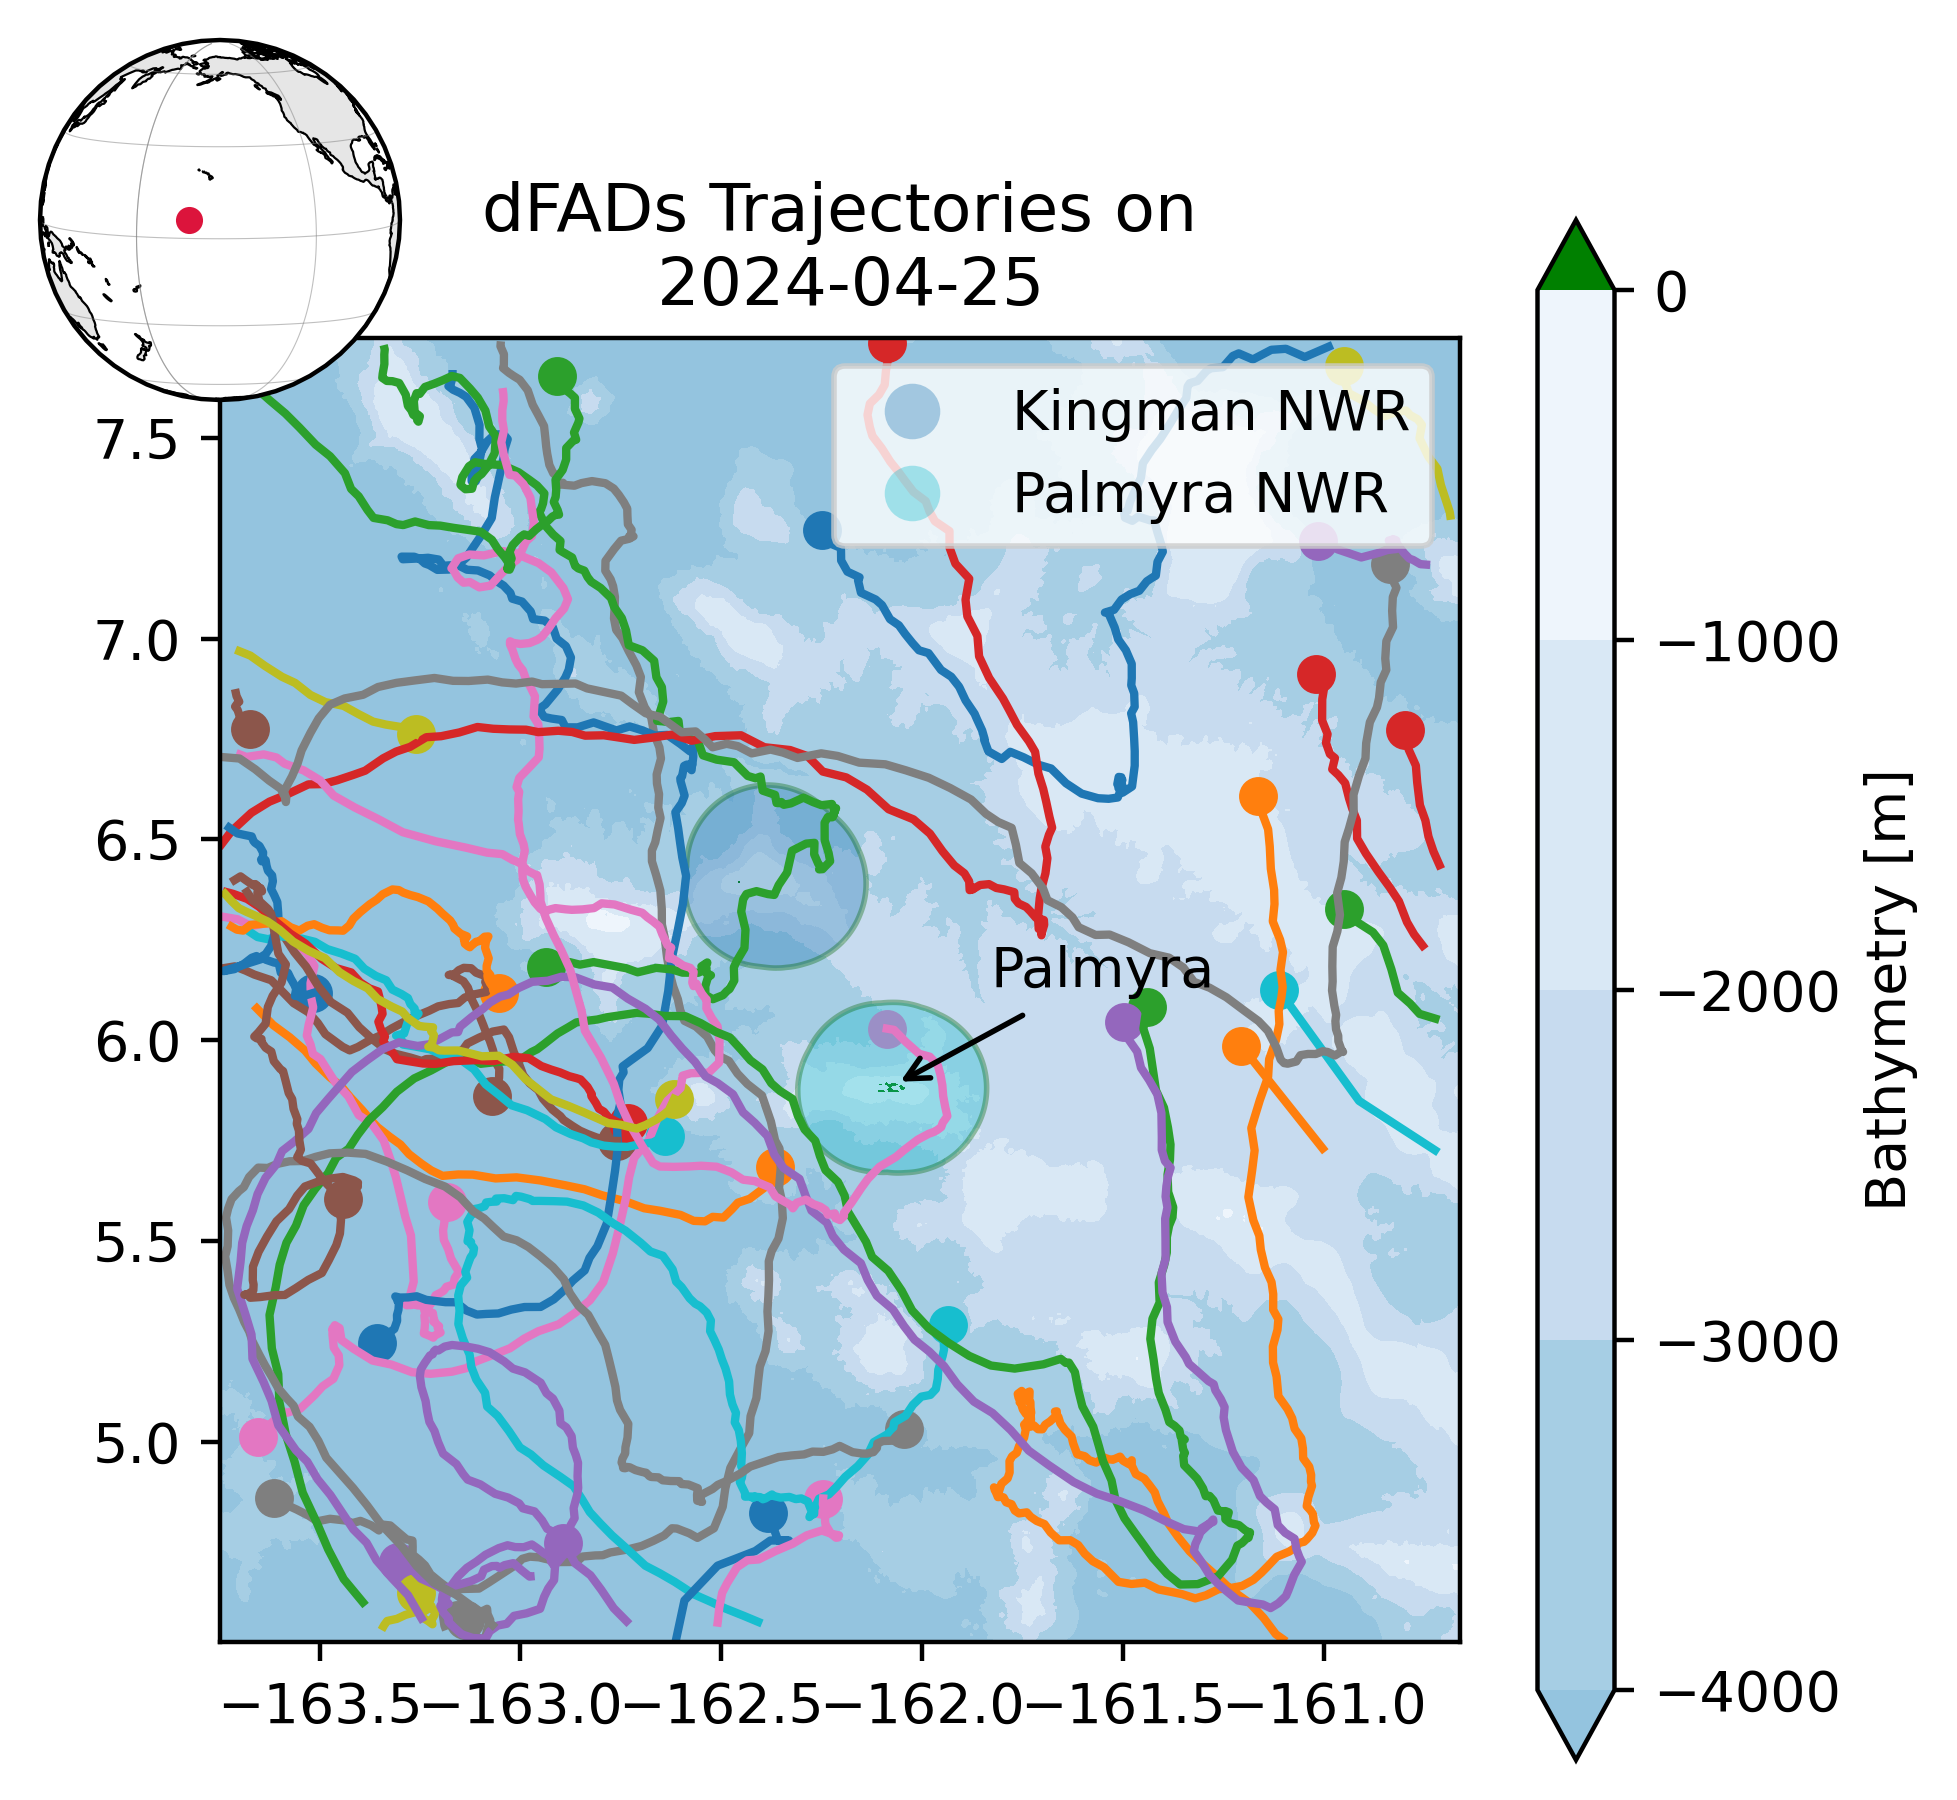

In [11]:
reload(plot)
## Plotting Data 
bouyids = activeday.index.unique()

fig, ax = plt.subplots(figsize = (5,5), dpi = 400)
fig, ax = plot.Add_bathymetry(fig, ax)

for id in bouyids: 
    traj = activeday.loc[id]
    if isinstance(traj, pd.Series):
        traj = traj.to_frame().T
    
    traj = traj.sort_values('TimeStamp')

    ax.plot(traj.lon, traj.lat)
    ax.scatter(traj.lon.iloc[-1], traj.lat.iloc[-1])

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

ax.set_title(f'dFADs Trajectories on\n {target_day.date()}')

# Center globe on the mean position of the latest point from each buoy
last_obs = activeday.sort_values("TimeStamp").groupby(level=0).tail(1)
center_lon = float(last_obs["lon"].mean())
center_lat = float(last_obs["lat"].mean())

# Place a small globe inset in the top-right corner of the existing axis
bbox = ax.get_position()  # in figure coordinates
w, h = 0.18, 0.18
x0 = bbox.x0 -w/2
y0 = bbox.y1 -h/2

globe_ax = fig.add_axes([x0, y0, w, h], projection=ccrs.Orthographic(center_lon+10, center_lat))
globe_ax.set_global()
globe_ax.add_feature(cfeature.LAND, facecolor="0.9")
globe_ax.add_feature(cfeature.OCEAN, facecolor="white")
globe_ax.coastlines(linewidth=0.4)
globe_ax.gridlines(linewidth=0.2, color="gray", alpha=0.5)

# Mark the region of interest on the globe
globe_ax.scatter(center_lon, center_lat, s=15, color="crimson", transform=ccrs.PlateCarree(), zorder=5)
lon, lat = plot.Palmyra_obj().xy
pal_lon, pal_lat =lon[0], lat[0]


ax.annotate( "Palmyra", xy=(pal_lon, pal_lat),xytext=(18, 18),textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=1, color="black"),fontsize=10,zorder=8)
dataNWR = gpd.read_file(r"Data\Palmyra_Shapefiles",  layer = 'PAL_KING_NWR_12nm')
ax = plot.plot_NWPs(ax, dataNWR)
# ax.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
#           fancybox=True, shadow=True, ncol=3)
fig.savefig("..\Figures\paper\FIG1.pdf" , format = 'pdf')

In [6]:
def segment(activeday):
    # Sort so segmenting is done in time order within each trajectory
    activeday = activeday.sort_values(['BuoyID', 'TimeStamp']).copy()

    # Time gap threshold for starting a new segment
    gap = pd.Timedelta(days=2)

    # Time difference between consecutive points per BuoyID
    activeday['deltat'] = activeday.groupby('BuoyID')['TimeStamp'].diff()

    # Segment id per BuoyID (0, 1, 2, ...)
    # increments whenever deltat >= gap
    activeday['segment_id'] = (
        activeday['deltat'].ge(gap)
        .groupby(activeday['BuoyID'])
        .cumsum()
        .astype(int)
    )

    # Optional: keep same indexing style as earlier cells
    activeday = activeday.set_index('BuoyID')
    return activeday

longlist3 = longlist.copy()
longlist3 = segment(longlist3)


In [7]:
## interpolate the longlist onto one hour intervals. 
## must cut dFAD trajectories into segments before I Interpolate.
import functions.funcs as funcs
reload(funcs)
longlist2 = longlist.copy()
longlist2 = segment(longlist2)
interp = longlist2.groupby(['BuoyID', 'segment_id'], observed=False).apply(
    funcs.interpolate_dFADs, dt = pd.Timedelta(hours = 1), columns = ['lat', 'lon'],
     include_groups = False).reset_index(level= ['BuoyID','segment_id']).reset_index(drop = True)

In [8]:
colors = [plt.matplotlib.colors.to_hex(c) for c in plt.cm.tab20.colors]

group_colors = {
    key: np.random.choice(colors)
    for key in interp.groupby(['BuoyID', 'segment_id']).groups
}

interp['color'] = [
    group_colors[(buoy, segment)]
    for buoy, segment in zip(interp['BuoyID'], interp['segment_id'])
]

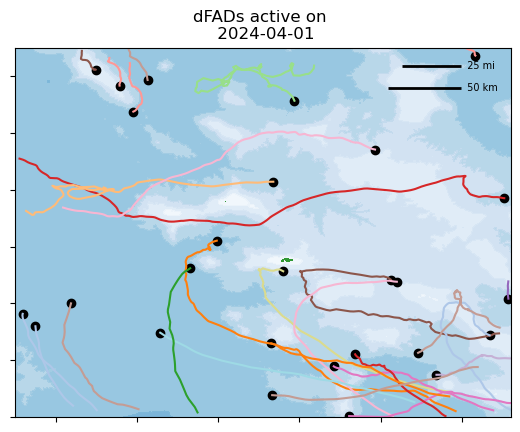

In [20]:
#3 annimation
import matplotlib.animation as animation
fig, ax = plt.subplots()
def target_date(date, longlist):
    target_time = date
    past = longlist[longlist.TimeStamp < pd.to_datetime(target_time)].copy()
    
    past['last_time'] =past.groupby('BuoyID', observed= False)['TimeStamp'].transform('last')
    past['last_time'] = pd.to_datetime(past['last_time'])
    past['last_time_diff'] = (past['last_time'] - target_time).abs()
    activeday = past[past['last_time_diff'] < pd.Timedelta(3*60, unit= 'minutes')].copy()
    activeday['deltat'] = activeday.groupby('BuoyID')['TimeStamp'].diff()
    gap = pd.Timedelta(days=2)

    # Build segment IDs that increment at each large time gap
    seg_id = activeday['deltat'].ge(gap).groupby(activeday['BuoyID']).cumsum()

    # Keep only the most recent segment per buoy (or all rows if no gap >= 2 days)
    activeday = activeday[seg_id == seg_id.groupby(activeday['BuoyID']).transform('max')].copy()
    activeday = activeday.set_index(['BuoyID'])
    return activeday

def draw_scalebars(ax, ref_lat=6.0):
    """Draw scale bars and return the resulting line/text artists."""
    cos_lat = np.cos(np.radians(ref_lat))
    km_per_deg_lon = 111.32 * cos_lat

    bars = [
        (16.0934 * 2.5 / km_per_deg_lon, "25 mi"),
        (10.0 * 5      / km_per_deg_lon, "50 km"),
    ]

    x_end   = 0.9
    y_start = 0.95
    dy      = 0.06

    xlim   = ax.get_xlim()
    ylim   = ax.get_ylim()
    x_span = xlim[1] - xlim[0]
    y_span = ylim[1] - ylim[0]

    artists = []
    for i, (width_deg, label) in enumerate(bars):
        y_frac       = y_start - i * dy
        x_end_data   = xlim[0] + x_end * x_span
        x_start_data = x_end_data - width_deg
        y_data       = ylim[0] + y_frac * y_span

        line, = ax.plot([x_start_data, x_end_data], [y_data, y_data],
                        color='black', lw=2, solid_capstyle='butt',
                        transform=ax.transData, zorder=10)
        txt = ax.text(x_end_data, y_data, f'  {label}',
                      va='center', ha='left', fontsize=7, zorder=10,
                      transform=ax.transData)
        artists.extend([line, txt])
    return artists

interp.TimeStamp = interp.TimeStamp.dt.round('h')
interp = interp.sort_values('TimeStamp')

# Draw bathymetry once and cache collections
plot.Add_bathymetry(fig, ax, colorbar=False)
bath_collections = list(ax.collections)

# Draw scale bars once on the final axis limits and cache artists
ax.set_xlim(-163.75, -160.7)
ax.set_ylim(4.5, 7.75)
scalebar_artists = draw_scalebars(ax)

def update(date):
    ax.clear()
    # Restore cached bathymetry collections
    for c in bath_collections:
        ax.add_collection(c)
    # Restore cached scale bar artists
    for a in scalebar_artists:
        ax.add_artist(a)

    activeday = target_date(date, interp)
    bouyids = activeday.index.unique()
    for id in bouyids: 
        traj = activeday.loc[id]
        if isinstance(traj, pd.Series):
            traj = traj.to_frame().T
        
        traj = traj.sort_values('TimeStamp')

        ax.plot(traj.lon, traj.lat,  color = traj.color.iloc[0])
        ax.scatter(traj.lon.iloc[-1], traj.lat.iloc[-1], color = 'k')
    ax.set_xlim(-163.75,-160.7)
    ax.set_ylim(4.5,7.75)
    ax.set_title(f'dFADs active on \n {date.date()}')
    ax.tick_params(labelbottom=False, labelleft=False)

dates = pd.date_range('2024-04-01', '2024-05-01', freq= pd.Timedelta(3, 'hour'))
ani = animation.FuncAnimation(fig, update, frames=dates, interval=100, blit=False)
ani.save(r"..\Figures\Animations\Active_dFADs_2024_jan.mp4", writer= 'ffmpeg')


<Axes.ArtistList of 1 collections>

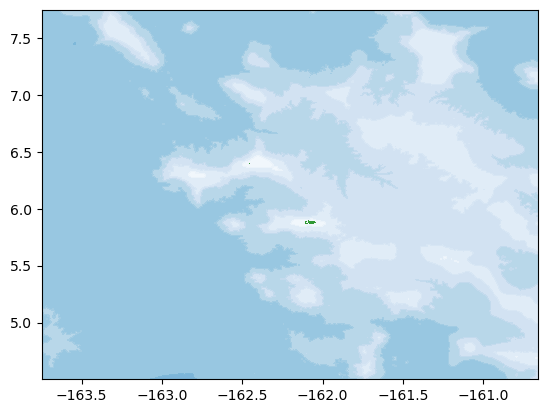

In [10]:
fig, ax = plt.subplots()
plot.Add_bathymetry(fig, ax, colorbar= False)
ax.plot(-161, 5)
ax.collections